In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Impostazioni stile per i grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

✅ Dataset trovato in: ./data/raw/
Distribuzione delle classi:
- MildDemented: 8960 immagini
- ModerateDemented: 6464 immagini
- NonDemented: 9600 immagini
- VeryMildDemented: 8960 immagini


/tmp/ipython-input-596/633574108.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


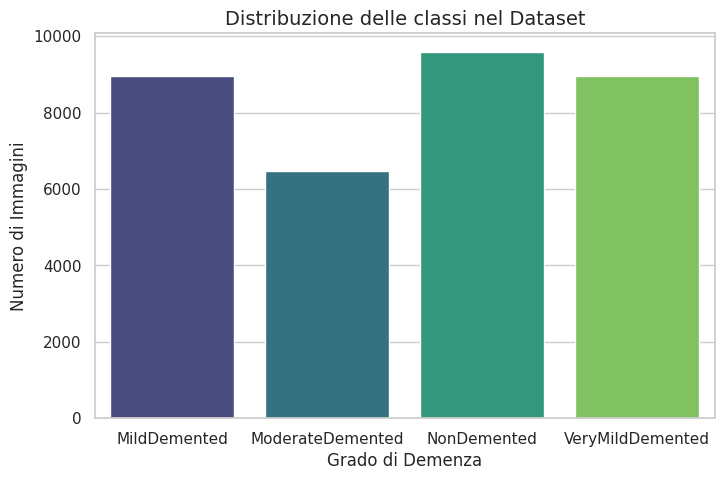

In [3]:
# Definiamo i possibili percorsi in base a dove stiamo eseguendo il codice
possible_paths = [
    "../data/raw/",                         # Se il notebook è in /notebooks (Standard GitHub)
    "./data/raw/",                          # Se eseguito dalla root della repository
    "/content/neurovisiondl-unict-dlcmm-Maccarrone-Brancaforte-Cassia/data/raw" # Fallback per Colab dalla root assoluta
]

DATA_DIR = None
for path in possible_paths:
    # Controlliamo se in questo percorso esiste almeno una delle cartelle delle classi
    if os.path.exists(os.path.join(path, "MildDemented")):
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError("⚠️ ERRORE: Impossibile trovare la cartella data/raw/. Assicurati di aver clonato la repo e scaricato i dati.")
else:
    print(f"✅ Dataset trovato in: {DATA_DIR}")

# Procedi con il caricamento
dataset_raw = datasets.ImageFolder(root=DATA_DIR)
classes = dataset_raw.classes
class_counts = {c: 0 for c in classes}

for _, label in dataset_raw:
    class_name = classes[label]
    class_counts[class_name] += 1

print("Distribuzione delle classi:")
for c, count in class_counts.items():
    print(f"- {c}: {count} immagini")

# Plot della distribuzione
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Distribuzione delle classi nel Dataset", fontsize=14)
plt.ylabel("Numero di Immagini", fontsize=12)
plt.xlabel("Grado di Demenza", fontsize=12)
plt.show()

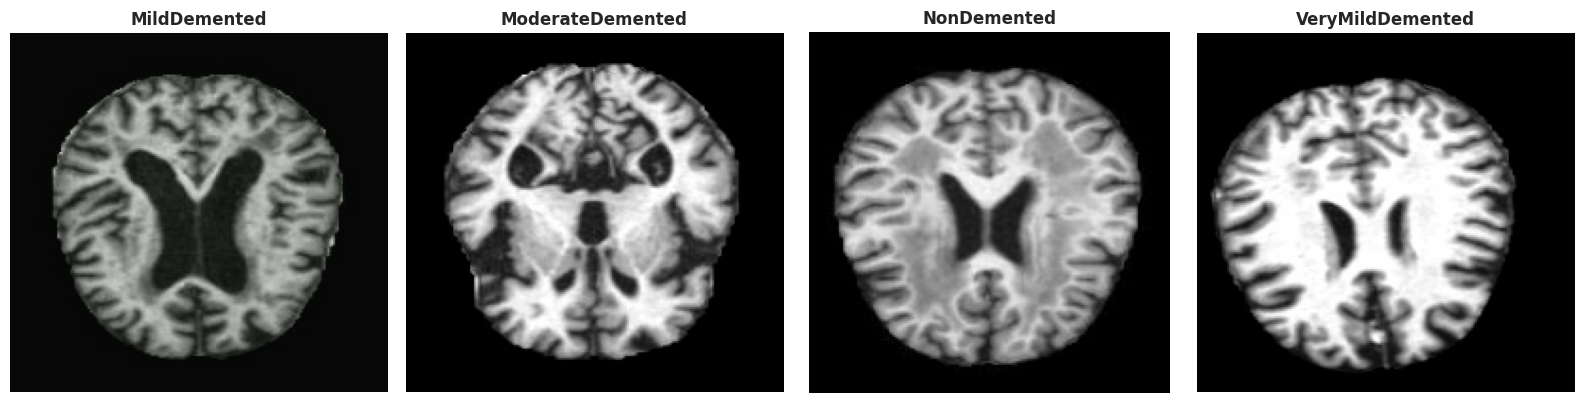

In [4]:
# Funzione per mostrare un'immagine per ogni classe
def plot_samples_per_class(dataset, classes):
    fig, axes = plt.subplots(1, len(classes), figsize=(16, 4))

    # Dizionario per tenere traccia delle classi già plottate
    plotted_classes = set()

    for img, label in dataset:
        class_name = classes[label]

        if class_name not in plotted_classes:
            idx = classes.index(class_name)
            ax = axes[idx]
            ax.imshow(img, cmap='gray') # Le MRI sono in scala di grigi
            ax.set_title(class_name, fontsize=12, fontweight='bold')
            ax.axis('off')
            plotted_classes.add(class_name)

        if len(plotted_classes) == len(classes):
            break

    plt.tight_layout()
    plt.show()

plot_samples_per_class(dataset_raw, classes)

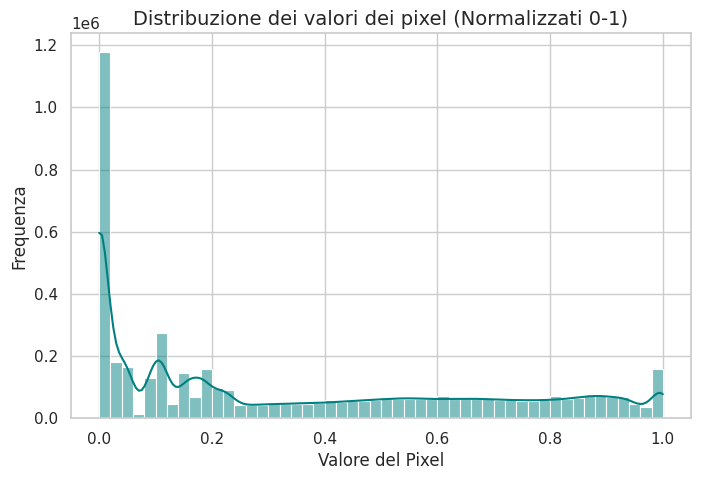

In [5]:
# Prendiamo un batch casuale convertito in tensori per analizzare i pixel
transform_tensor = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_tensor = datasets.ImageFolder(root=DATA_DIR, transform=transform_tensor)
loader = DataLoader(dataset_tensor, batch_size=32, shuffle=True)

images, _ = next(iter(loader))

# Appiattiamo il batch di immagini in un array 1D
pixel_values = images.numpy().flatten()

plt.figure(figsize=(8, 5))
sns.histplot(pixel_values, bins=50, color='teal', kde=True)
plt.title("Distribuzione dei valori dei pixel (Normalizzati 0-1)", fontsize=14)
plt.xlabel("Valore del Pixel", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.show()